# Black Swan Dashboard - Weekly Predictor
**Rulare:** In fiecare luni dimineata (sau oricand in cursul saptamanii)  
**Output:** Probabilitatea de V-shape recovery pentru saptamana curenta  
**Model:** Voting Ensemble (LightGBM + Naive Bayes + SVM RBF) | AUC 0.751

## 1. Import si Incarcare Model

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import json
import os
import warnings
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

ensemble = pickle.load(open('models/v4_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('models/v4_scaler.pkl',   'rb'))

with open('models/v4_model_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS      = meta['feature_cols']
OPTIMAL_THRESHOLD = meta['optimal_threshold']
TODAY             = datetime.today().strftime('%Y-%m-%d')

print('Model incarcat:', meta['model_name'])
print('AUC antrenare:', meta['auc'])
print('Threshold optim:', OPTIMAL_THRESHOLD)
print('Features:', len(FEATURE_COLS))
print('Data curenta:', TODAY)

Model incarcat: LightGBM
AUC antrenare: 0.7637
Threshold optim: 0.51
Features: 14
Data curenta: 2026-04-14


## 2. Descarcare Date Recente

In [32]:
START_DATE = (datetime.today() - timedelta(days=600)).strftime('%Y-%m-%d')
sp500 = yf.download('^GSPC', start=START_DATE, auto_adjust=True)
sp500 = sp500[['Close', 'Volume']].copy()
sp500.columns = ['SP500_Close', 'SP500_Volume']

vix = yf.download('^VIX', start=START_DATE, auto_adjust=True)
vix = vix[['Close']].copy()
vix.columns = ['VIX_raw']

daily = sp500.join(vix, how='left')
daily.index = pd.to_datetime(daily.index)

print('Date descarcate:', daily.index[0].date(), '->', daily.index[-1].date())
print('Total zile:', len(daily))
print(daily.tail(3))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Date descarcate: 2024-08-22 -> 2026-04-13
Total zile: 410
            SP500_Close  SP500_Volume    VIX_raw
Date                                            
2026-04-09  6824.660156    4912410000  19.490000
2026-04-10  6816.890137    4393220000  19.230000
2026-04-13  6886.240234    2885789000  19.120001


## 3. Detectare Criza

In [33]:
TRIGGER_THRESHOLD = 0.07
TRIGGER_WINDOW    = 20

recent_max  = daily['SP500_Close'].rolling(TRIGGER_WINDOW).max()
daily['Drawdown_from_Peak'] = (daily['SP500_Close'] - recent_max) / recent_max

current_price    = daily['SP500_Close'].iloc[-1]
current_drawdown = daily['Drawdown_from_Peak'].iloc[-1]
current_vix      = daily['VIX_raw'].iloc[-1]

crisis_active = bool(current_drawdown <= -TRIGGER_THRESHOLD)

print('SP500 curent:        ', round(float(current_price), 2))
print('Drawdown de la peak: ', str(round(float(current_drawdown) * 100, 2)) + '%')
print('VIX curent:          ', round(float(current_vix), 2))
print('')

if crisis_active:
    crisis_start_mask = daily['Drawdown_from_Peak'] <= -TRIGGER_THRESHOLD
    crisis_start_date = daily[crisis_start_mask].index[0]
    weeks_in_crisis   = max(1, int((daily.index[-1] - crisis_start_date).days / 7))
    phase = 1 if weeks_in_crisis <= 6 else (2 if weeks_in_crisis <= 18 else 3)
    phase_labels = {1: 'Early (0-6 saptamani)', 2: 'Mid (7-18 saptamani)', 3: 'Late (19+ saptamani)'}
    print('STATUS: CRIZA ACTIVA')
    print('Inceput criza:     ', crisis_start_date.date())
    print('Saptamani in criza:', weeks_in_crisis)
    print('Faza:              ', phase_labels[phase])
else:
    phase           = 1
    weeks_in_crisis = 0
    print('STATUS: FARA CRIZA ACTIVA')
    print('Drawdown curent sub threshold de', str(TRIGGER_THRESHOLD*100) + '%')

SP500 curent:         6886.24
Drawdown de la peak:  0.0%
VIX curent:           19.12

STATUS: FARA CRIZA ACTIVA
Drawdown curent sub threshold de 7.000000000000001%


## 4. Feature Engineering + Agregare Saptamanala

In [34]:
df = daily.copy()

# Indicatori pe date zilnice
df['MA50']             = df['SP500_Close'].rolling(50).mean()
df['MA200']            = df['SP500_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()
df['Return_1d']        = df['SP500_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
df['Local_Min_20d']    = df['SP500_Close'].rolling(20).min()
df['Dist_Local_Min']   = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['SP500_Close'])

def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals   = series.values
    x      = np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']   = rolling_slope(df['VIX_raw'], 20)
df['SP500_Trend_20d'] = rolling_slope(df['SP500_Close'], 20)

# Agregare saptamanala cu coloane explicit numite
agg_rules = {
    'SP500_Close'     : 'last',
    'SP500_Volume'    : 'sum',
    'VIX_raw'         : 'mean',
    'Dist_MA50'       : 'last',
    'Dist_MA200'      : 'last',
    'Dist_52w_High'   : 'last',
    'RSI'             : 'last',
    'Dist_Local_Min'  : 'last',
    'VIX_Ratio'       : 'mean',
    'VIX_Trend_20d'   : 'mean',
    'SP500_Trend_20d' : 'last',
    'Realized_Vol_10d': 'mean',
}

weekly = df.resample('W-FRI').agg(agg_rules)

# Redenumim VIX_raw -> VIX pentru a corespunde cu feature_cols
weekly = weekly.rename(columns={'VIX_raw': 'VIX'})

# Features saptamanale
weekly['Return_1w']    = weekly['SP500_Close'].pct_change()
weekly['Return_4w']    = weekly['SP500_Close'].pct_change(4)
weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()
weekly['Phase']        = phase

weekly.dropna(subset=['Return_1w'], inplace=True)

# Verificare: nicio coloana duplicata
weekly = weekly.loc[:, ~weekly.columns.duplicated()]

print('Features calculate. Ultima saptamana:', weekly.index[-1].date())
print('Nr coloane weekly:', len(weekly.columns))
print('\nVerificare FEATURE_COLS disponibile:')
missing = [f for f in FEATURE_COLS if f not in weekly.columns]
print('  Lipsa:', missing if missing else 'Niciuna, totul e ok.')

Features calculate. Ultima saptamana: 2026-04-17
Nr coloane weekly: 16

Verificare FEATURE_COLS disponibile:
  Lipsa: Niciuna, totul e ok.


## 5. Predictie Saptamana Curenta

In [35]:
X_current = weekly[FEATURE_COLS].iloc[[-1]]

if X_current.isnull().any().any():
    print('ATENTIE: Features incomplete. Mai asteapta date.')
else:
    # Folosim .values pentru a evita orice conflict de metadata sklearn
    X_scaled = scaler.transform(np.array(X_current.values, dtype=np.float64).reshape(1, -1))
    proba_v    = float(ensemble.predict_proba(X_scaled)[0][1])
    proba_nonv = 1 - proba_v
    signal     = 'V-SHAPE' if proba_v >= OPTIMAL_THRESHOLD else 'NON-V'

    separator = '=' * 45
    print(separator)
    print('BLACK SWAN DASHBOARD -', TODAY)
    print(separator)
    print('')
    print('SP500:               ', round(float(current_price), 2))
    print('VIX:                 ', round(float(current_vix), 2))
    print('Drawdown de la peak: ', str(round(float(current_drawdown)*100, 2)) + '%')
    print('Saptamani in criza:  ', weeks_in_crisis if crisis_active else 'N/A')
    print('')
    print('P(V-shape):  ', str(round(proba_v * 100, 1)) + '%')
    print('P(Non-V):    ', str(round(proba_nonv * 100, 1)) + '%')
    print('Threshold:   ', str(round(OPTIMAL_THRESHOLD * 100)) + '%')
    print('')
    print('SEMNAL:      ', signal)
    print(separator)
    print('')
    if signal == 'V-SHAPE':
        print('Interpretare: Modelul estimeaza o recuperare rapida')
        print('              (>5% in urmatoarele 60 de zile lucratoare)')
    else:
        print('Interpretare: Modelul nu detecteaza semnal de recuperare rapida.')
        print('              Risc de continuare a scaderii sau recuperare lenta.')

BLACK SWAN DASHBOARD - 2026-04-14

SP500:                6886.24
VIX:                  19.12
Drawdown de la peak:  0.0%
Saptamani in criza:   N/A

P(V-shape):   15.6%
P(Non-V):     84.4%
Threshold:    51%

SEMNAL:       NON-V

Interpretare: Modelul nu detecteaza semnal de recuperare rapida.
              Risc de continuare a scaderii sau recuperare lenta.


## 6. Dashboard Vizual

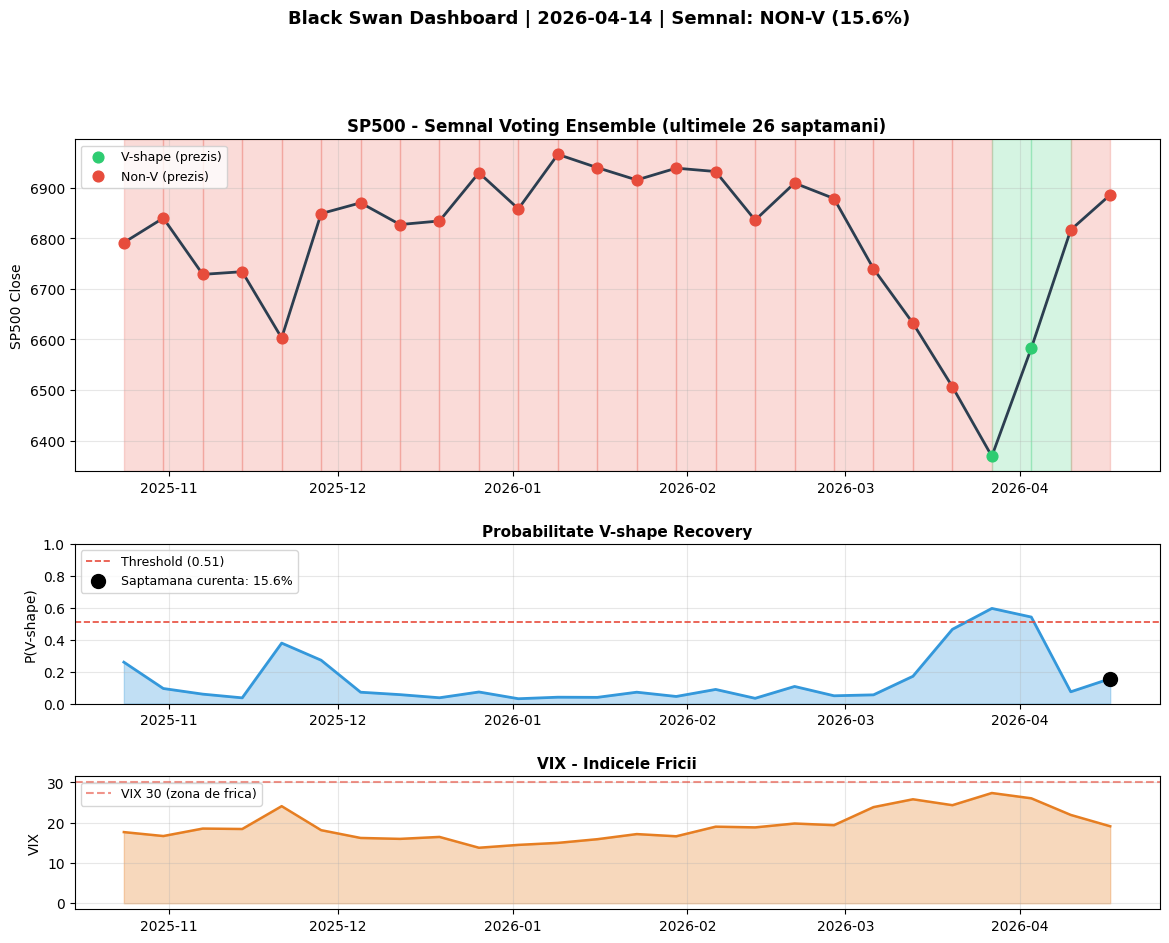

Salvat: plots/dashboard_2026-04-14.png


In [36]:
# Ultimele 26 saptamani cu toate features disponibile
extra_cols  = [c for c in ['SP500_Close', 'VIX'] if c not in FEATURE_COLS]
weekly_plot = weekly[FEATURE_COLS + extra_cols].dropna().iloc[-26:]
X_plot   = weekly_plot[FEATURE_COLS]
X_plot_s = scaler.transform(X_plot.values)
probas   = ensemble.predict_proba(X_plot_s)[:, 1]
preds    = (probas >= OPTIMAL_THRESHOLD).astype(int)
prices   = weekly_plot['SP500_Close']
vix_plot = weekly_plot['VIX']

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[2.5, 1.2, 1], hspace=0.35)

# --- Plot 1: SP500 colorat dupa semnal ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(prices.index, prices.values, color='#2c3e50', linewidth=2, zorder=3)

for i in range(len(X_plot) - 1):
    color = '#2ecc71' if preds[i] == 1 else '#e74c3c'
    ax1.axvspan(X_plot.index[i], X_plot.index[i+1], alpha=0.2, color=color)

for lbl, color, label in [(1, '#2ecc71', 'V-shape (prezis)'), (0, '#e74c3c', 'Non-V (prezis)')]:
    mask = preds == lbl
    if mask.any():
        ax1.scatter(prices.index[mask], prices.values[mask],
                   color=color, s=60, zorder=5, label=label)

ax1.set_title('SP500 - Semnal Voting Ensemble (ultimele 26 saptamani)', fontsize=12, fontweight='bold')
ax1.set_ylabel('SP500 Close')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Probabilitate P(V-shape) ---
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(X_plot.index, probas, alpha=0.3, color='#3498db')
ax2.plot(X_plot.index, probas, color='#3498db', linewidth=2)
ax2.axhline(OPTIMAL_THRESHOLD, color='#e74c3c', linestyle='--', linewidth=1.2,
            label='Threshold (' + str(round(OPTIMAL_THRESHOLD, 2)) + ')')
ax2.scatter([X_plot.index[-1]], [probas[-1]], color='black', s=100, zorder=5,
            label='Saptamana curenta: ' + str(round(float(probas[-1])*100, 1)) + '%')
ax2.set_ylabel('P(V-shape)')
ax2.set_ylim(0, 1)
ax2.set_title('Probabilitate V-shape Recovery', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: VIX ---
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(vix_plot.index, vix_plot.values, alpha=0.3, color='#e67e22')
ax3.plot(vix_plot.index, vix_plot.values, color='#e67e22', linewidth=1.8)
ax3.axhline(30, color='#e74c3c', linestyle='--', alpha=0.6, label='VIX 30 (zona de frica)')
ax3.set_ylabel('VIX')
ax3.set_title('VIX - Indicele Fricii', fontsize=11, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.suptitle(
    'Black Swan Dashboard | ' + TODAY + ' | Semnal: ' + signal + ' (' + str(round(proba_v*100, 1)) + '%)',
    fontsize=13, fontweight='bold', y=1.01
)
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/dashboard_' + TODAY + '.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/dashboard_' + TODAY + '.png')

## 7. Istoric Semnale

In [37]:
log_file = 'dashboard_log.csv'

new_row = pd.DataFrame([{
    'date'            : TODAY,
    'sp500'           : round(float(current_price), 2),
    'vix'             : round(float(current_vix), 2),
    'drawdown_pct'    : round(float(current_drawdown) * 100, 2),
    'p_vshape'        : round(float(proba_v), 4),
    'signal'          : signal,
    'crisis_active'   : crisis_active,
    'weeks_in_crisis' : weeks_in_crisis,
    'phase'           : phase
}])

if os.path.exists(log_file):
    log = pd.read_csv(log_file)
    log = pd.concat([log, new_row], ignore_index=True)
else:
    log = new_row

log.to_csv(log_file, index=False)
print('Log actualizat:', log_file)
print('\nIstoricul semnalelor:')
print(log.tail(10).to_string(index=False))

Log actualizat: dashboard_log.csv

Istoricul semnalelor:
      date   sp500   vix  drawdown_pct  p_vshape signal  crisis_active  weeks_in_crisis  phase
2026-04-14 6886.24 19.12           0.0    0.1564  NON-V          False                0      1
2026-04-14 6886.24 19.12           0.0    0.1564  NON-V          False                0      1
